# 📉 Sesión 3 — Severidad en la práctica: el ramo y las transformaciones
## Matemáticas Actuariales para Seguro de Daños, Fianzas y Reaseguro · UNAM

---

**Semana 1 · Severidad** · **Herramienta:** Python
**Proyecto:** módulo de severidad de la nota técnica

---

> **Objetivo:** ver que la severidad que modelas **no es la cruda**. El ramo la ubica y la póliza la
> transforma (deducible, límite, coaseguro). Aprenderemos a aplicar esas transformaciones, a
> reconocer **truncamiento y censura**, y por qué ignorarlos **sesga el ajuste** y la prima.
>
> 🟢 Las celdas normales las corremos juntos. **✏️ Las de Ejercicio las completas tú.**

## Contenido
1. [Entorno](#1)
2. [La severidad cambia entre ramos](#2)
3. [La severidad cruda y su ajuste](#3)
4. [Deducible: aplicar la transformación](#4)
5. [El sesgo de ignorar el truncamiento](#5)
6. [Límite y suma asegurada (censura)](#6)
7. [El efecto en la prima](#7)
8. [Cierre → Práctica A1](#8)

---

---
<a id='1'></a>
## 1. Entorno

In [1]:
# ─── Entorno ────────────────────────────────────────────────────────────────
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize

np.random.seed(7)
plt.rcParams["figure.figsize"] = (9, 4.2)
print("✓ listo")

✓ listo


---
<a id='2'></a>
## 2. La severidad cambia entre ramos

Un siniestro de auto no vive en la misma escala que uno marítimo. Antes de simular o ajustar,
conviene saber **en qué rango** se mueve el ramo.

In [2]:
# ─── Rango típico por ramo (mediana, p95, p99) ─────────────────────────────
ramos = {
    "Autos":       stats.lognorm(s=0.7, scale=60),
    "Incendio":    stats.lognorm(s=0.9, scale=400),
    "Resp. civil": stats.lognorm(s=1.2, scale=250),
    "Marítimo":    stats.lognorm(s=0.8, scale=1200),
}
filas = []
for nom, d in ramos.items():
    filas.append({"Ramo": nom, "mediana": d.ppf(0.50), "p95": d.ppf(0.95), "p99": d.ppf(0.99)})
tabla_ramos = pd.DataFrame(filas).set_index("Ramo").round(0)
print(tabla_ramos.to_string())
print("\nMismo tipo de distribución, escalas y colas muy distintas: el ramo fija el rango.")

             mediana     p95     p99
Ramo                                
Autos           60.0   190.0   306.0
Incendio       400.0  1758.0  3246.0
Resp. civil    250.0  1800.0  4077.0
Marítimo      1200.0  4474.0  7717.0

Mismo tipo de distribución, escalas y colas muy distintas: el ramo fija el rango.


### ✏️ Ejercicio 1 — el rango de un ramo

1. Elige un ramo de la tabla y calcula qué proporción de siniestros supera **el doble de su p95**.
2. ¿En qué intervalo (aprox. p1 a p99) tiene sentido simular montos para ese ramo?

In [3]:
# Tu código aquí 👇
# Pista: d = ramos["Autos"];  d.sf(2*d.ppf(0.95)) ;  d.ppf(0.01), d.ppf(0.99)


---
<a id='3'></a>
## 3. La severidad cruda y su ajuste

Generamos una muestra de severidad **cruda** (ground-up: el monto real del daño, sin póliza de por
medio) y ajustamos una lognormal como base.

In [4]:
# ─── Severidad cruda (ground-up) ───────────────────────────────────────────
real = stats.lognorm(s=0.9, scale=180)      # la "verdad" que normalmente NO conocemos
x = real.rvs(5_000)

pr_real = stats.lognorm.fit(x, floc=0)
print(f"Ajuste a datos CRUDOS   → s={pr_real[0]:.3f}, scale={pr_real[2]:.1f}")
print(f"Media ajustada           → {stats.lognorm(*pr_real).mean():,.1f}")
print(f"Media empírica           → {x.mean():,.1f}")

Ajuste a datos CRUDOS   → s=0.895, scale=176.4
Media ajustada           → 263.5
Media empírica           → 262.4


---
<a id='4'></a>
## 4. Deducible: aplicar la transformación

Con un deducible $d$, la aseguradora paga $Y=\max(X-d,0)$. Hay dos situaciones distintas:

- **Censura:** sabes que hubo siniestro, pero muchos pagan 0 (los que no superan $d$).
- **Truncamiento:** si los siniestros bajo $d$ **no se reportan**, ni siquiera los ves.

Deducible d = 200
Siniestros totales        : 5,000
Pagan 0 (por debajo de d) : 55.4%   ← censura
Siniestros que 've' la aseguradora si hay truncamiento: 2,232


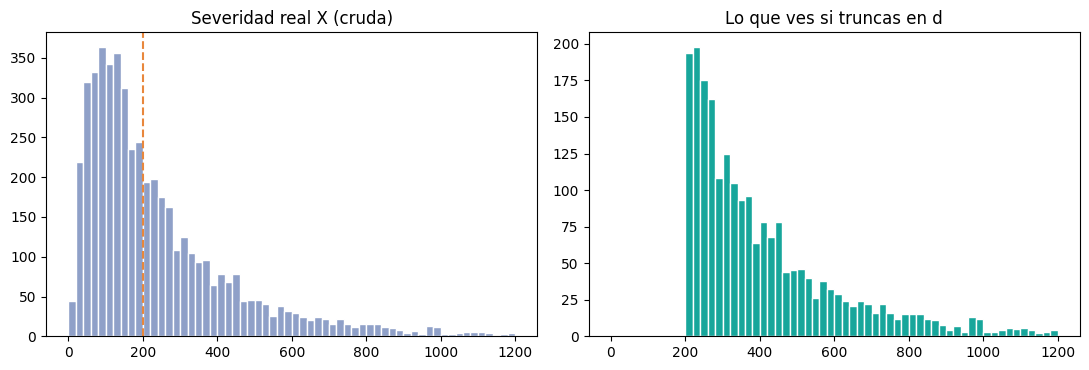

In [5]:
# ─── Aplicar un deducible d ─────────────────────────────────────────────────
d = 200
pago      = np.maximum(x - d, 0)          # lo que paga la aseguradora
observado = x[x > d]                        # lo que ves si los < d NO se reportan (truncado)

print(f"Deducible d = {d}")
print(f"Siniestros totales        : {len(x):,}")
print(f"Pagan 0 (por debajo de d) : {(x <= d).mean():.1%}   ← censura")
print(f"Siniestros que 've' la aseguradora si hay truncamiento: {len(observado):,}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].hist(x, bins=60, range=(0, 1200), color="#8FA0C8", edgecolor="white"); ax[0].axvline(d, color="#E8873C", ls="--")
ax[0].set_title("Severidad real X (cruda)")
ax[1].hist(observado, bins=60, range=(0, 1200), color="#17A69B", edgecolor="white")
ax[1].set_title("Lo que ves si truncas en d")
plt.tight_layout(); plt.show()

### ✏️ Ejercicio 2 — censura y truncamiento

Con **otro** deducible (por ejemplo $d=100$):
1. ¿Qué porcentaje de siniestros paga 0 (censura)?
2. ¿Cuántos siniestros desaparecen de tu muestra si hay truncamiento?

In [6]:
# Tu código aquí 👇
# Pista: (x <= 100).mean()  ;  (x > 100).sum()


---
<a id='5'></a>
## 5. El sesgo de ignorar el truncamiento

Aquí está la lección. Si ajustas una lognormal a los datos **truncados** como si fueran crudos,
el ajuste sale **sesgado**. La forma correcta usa la densidad **condicional** $f(x)/S(d)$.

                           s     scale       media
Verdad                 0.900     180.0       269.9
Ingenuo (sesgado)      0.509     388.6       442.4
Truncado (correcto)    0.870     183.7       268.2


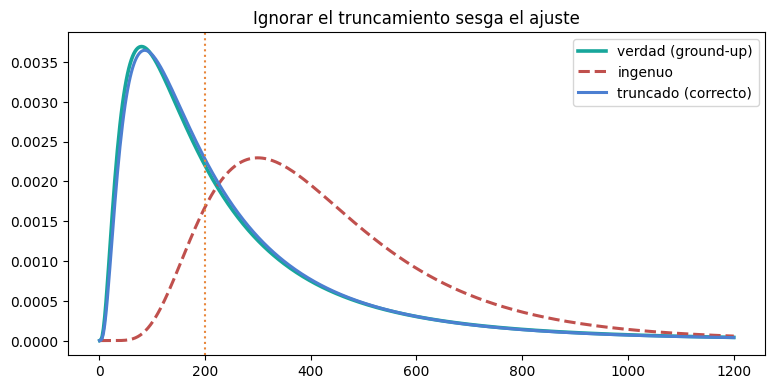

In [7]:
# ─── Ajuste ingenuo vs. ajuste truncado (correcto) ─────────────────────────
obs = x[x > d]                                  # datos truncados por el deducible

# (a) INGENUO: ajusta como si fueran crudos
pr_naive = stats.lognorm.fit(obs, floc=0)

# (b) CORRECTO: máxima verosimilitud TRUNCADA  → resta n·log S(d)
def nll_trunc(params, datos, d):
    s, scale = params
    if s <= 0 or scale <= 0:
        return np.inf
    dist = stats.lognorm(s, scale=scale)
    return -(np.sum(dist.logpdf(datos)) - len(datos) * np.log(dist.sf(d)))

res = minimize(nll_trunc, x0=[1.0, np.median(obs)], args=(obs, d), method="Nelder-Mead")
s_c, scale_c = res.x

print(f"{'':20}{'s':>8}{'scale':>10}{'media':>12}")
print(f"{'Verdad':20}{0.9:>8.3f}{180:>10.1f}{real.mean():>12,.1f}")
print(f"{'Ingenuo (sesgado)':20}{pr_naive[0]:>8.3f}{pr_naive[2]:>10.1f}{stats.lognorm(*pr_naive).mean():>12,.1f}")
print(f"{'Truncado (correcto)':20}{s_c:>8.3f}{scale_c:>10.1f}{stats.lognorm(s_c, scale=scale_c).mean():>12,.1f}")

xx = np.linspace(1, 1200, 500)
plt.plot(xx, real.pdf(xx), color="#17A69B", lw=2.6, label="verdad (ground-up)")
plt.plot(xx, stats.lognorm(*pr_naive).pdf(xx), color="#C0504D", lw=2.2, ls="--", label="ingenuo")
plt.plot(xx, stats.lognorm(s_c, scale=scale_c).pdf(xx), color="#4C7FD1", lw=2.2, label="truncado (correcto)")
plt.axvline(d, color="#E8873C", ls=":"); plt.title("Ignorar el truncamiento sesga el ajuste")
plt.legend(); plt.show()

### ✏️ Ejercicio 3 — mide el sesgo

1. Repite el ajuste **ingenuo** con un deducible más grande, $d=300$.
2. Calcula el error relativo de su media contra la verdad: `(media_ingenua - real.mean())/real.mean()`.
3. ¿El sesgo crece o baja al subir el deducible? ¿Por qué?

In [8]:
# Tu código aquí 👇
# Pista: obs2 = x[x > 300];  pr2 = stats.lognorm.fit(obs2, floc=0)


---
<a id='6'></a>
## 6. Límite y suma asegurada (censura por la derecha)

Con un límite (o suma asegurada) $L$, la aseguradora paga $\min(X,L)$: lo que exceda se **amontona**
en $L$. La prima con límite es la **esperanza limitada** $E[\min(X,L)]$.

Límite L = 700
Masa amontonada en L: P(X>L) = 5.9%
E[min(X,L)] empírica : 238.3
E[min(X,L)] modelo   : 242.6
E[X] sin límite      : 262.4   ← la cobertura con límite cuesta menos


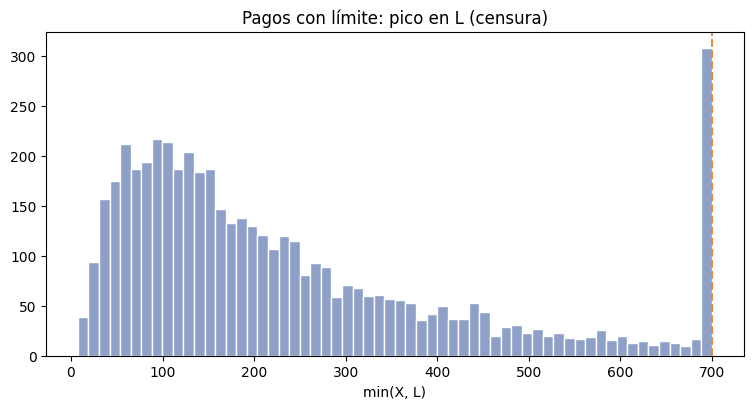

In [9]:
# ─── Aplicar un límite L ────────────────────────────────────────────────────
L = 700
pago_lim = np.minimum(x, L)

masa_en_L = (x > L).mean()
lev_emp   = pago_lim.mean()
lev_mod   = real.expect(lambda t: min(t, L))

print(f"Límite L = {L}")
print(f"Masa amontonada en L: P(X>L) = {masa_en_L:.1%}")
print(f"E[min(X,L)] empírica : {lev_emp:,.1f}")
print(f"E[min(X,L)] modelo   : {lev_mod:,.1f}")
print(f"E[X] sin límite      : {x.mean():,.1f}   ← la cobertura con límite cuesta menos")

plt.hist(pago_lim, bins=60, color="#8FA0C8", edgecolor="white")
plt.axvline(L, color="#E8873C", ls="--"); plt.title("Pagos con límite: pico en L (censura)")
plt.xlabel("min(X, L)"); plt.show()

### ✏️ Ejercicio 4 — la esperanza limitada

1. Calcula $E[\min(X,L)]$ (empírica) para $L=400$ y $L=1000$.
2. ¿Qué fracción de la prima cruda $E[X]$ representa cada una?

In [10]:
# Tu código aquí 👇
# Pista: np.minimum(x, 400).mean()  ;  .../ x.mean()


---
<a id='7'></a>
## 7. El efecto en la prima

Cada transformación cambia la **prima pura**. La comparamos, empíricamente, sobre la misma cartera.

In [11]:
# ─── Prima pura bajo distintas transformaciones ────────────────────────────
d, L, alpha = 200, 700, 0.8
prima = {
    "Cruda  E[X]":                         x.mean(),
    "Con deducible  E[max(X-d,0)]":        np.maximum(x - d, 0).mean(),
    "Con límite  E[min(X,L)]":             np.minimum(x, L).mean(),
    "Deducible + límite":                  np.minimum(np.maximum(x - d, 0), L - d).mean(),
    "Coaseguro alpha·E[max(X-d,0)]":       alpha * np.maximum(x - d, 0).mean(),
}
for k, v in prima.items():
    print(f"{k:<34} {v:>10,.1f}")
print("\nCada cláusula de la póliza mueve la prima. Por eso hay que modelar la severidad")
print("TRANSFORMADA que corresponde al producto — no la cruda a secas.")

Cruda  E[X]                             262.4
Con deducible  E[max(X-d,0)]            113.8
Con límite  E[min(X,L)]                 238.3
Deducible + límite                       89.8
Coaseguro alpha·E[max(X-d,0)]            91.0

Cada cláusula de la póliza mueve la prima. Por eso hay que modelar la severidad
TRANSFORMADA que corresponde al producto — no la cruda a secas.


### ✏️ Ejercicio 5 — arma tu combinación

1. Elige un deducible, un límite y un coaseguro y calcula la prima pura resultante.
2. Compárala con la prima cruda: ¿cuánto la reduce cada cláusula?

In [12]:
# Tu código aquí 👇


---
<a id='8'></a>
## 8. Cierre → Práctica A1

Ya con criterio, el laboratorio de tu equipo (Práctica A1) es:

1. **Ubica** el rango y la cola típica del ramo de tu equipo.
2. **Ajusta** la severidad con las candidatas de la sesión anterior.
3. **Aplica y visualiza** el efecto de deducible, límite y coaseguro sobre esa severidad.
4. **Reporta** cómo esas transformaciones mueven la prima pura.
5. **Distingue** siempre qué es dato crudo (ground-up) y qué es dato transformado.

> Con esto el ajuste deja de ser “un histograma pelón”: sabes qué modelas y por qué.
> Súbelo a tu carpeta del repositorio en GitHub.

---
*Matemáticas Actuariales para Seguro de Daños, Fianzas y Reaseguro · Semana 1 · Sesión 3*